In [3]:
!pip install sentence-transformers
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [4]:
import faiss, pandas as pd, numpy as np
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util

What subset of transformers models would be best to try?

In [46]:
MODELS = {
    "MiniLM-L6": "all-MiniLM-L6-v2",
    #"mpnet": "all-mpnet-base-v2",
    #"BERT-base": "bert-base-nli-mean-tokens",
    #"BERT-base-uncased": "bert-base-uncased",
    "BERT-base-cased": "bert-base-cased",
    #"BERT-large": "bert-large-uncased",
    "RoBERTa": "all-roberta-large-v1"
}

In [51]:
model_name = MODELS["MiniLM-L6"]
#model_name = MODELS["BERT-base-cased"]
#model_name = MODELS["RoBERTa"]
model = SentenceTransformer(model_name)

How about a set of experiments with different number length too. So dataset1 includes numbers 0-10, dataset2 0-100, and so on.
Then, let's compare performance between number vs spell-out.
- I think it also had trouble with floats?


In [7]:
# Load the dataset
text_path = "ages.txt" # back in the pycharm environment it will have to change to data/ages.txt

sentences = []
with open(text_path, "r") as f:
    for line in f:
        sentences.append(line.strip())

print("Number of sentences:", len(sentences))
print(sentences[:10])

Number of sentences: 100
['My age is 91', 'My age is 94', 'My age is 27', 'My age is 85', 'My age is 67', 'My age is 84', 'My age is 71', 'My age is 85', 'My age is 61', 'My age is 78']


In [ ]:
"""
Saving Embeddings with FAISS for later when the dataset is bigger.
embeddings = []
BATCH = 128
for i in tqdm(range(0, len(sentences), BATCH)):
  batch = sentences[i:i+BATCH]
  emb = model.encode(batch)
  embeddings.append(emb)

embeddings = np.vstack(embeddings)

index = faiss.IndexFlatL2(model.get_sentence_embedding_dimension())
index.add(embeddings)"""

100%|██████████| 1/1 [00:00<00:00,  1.32it/s]


In [31]:
def failproof(query_age, sentences):
  return min(sentences, key=lambda x: abs(int(x.split()[-1]) - query_age))

In [9]:
def simplest_query(age:int, sentences):
  query_age = str(age)
  emb_query = model.encode(query_age, convert_to_tensor=True)
  emb_sentences = model.encode(sentences, convert_to_tensor=True)
  similarities = util.cos_sim(emb_query, emb_sentences)[0]
  #similarities = util.dot_score(emb_query, emb_sentences)[0]

  best_idx = int(similarities.argmax())
  return sentences[best_idx]

In [10]:
def compare(age, sentences):
  return simplest_query(age, sentences), failproof(age)

In [ ]:
transformer, math = compare(70, sentences)
print("transformer: ", transformer)
print("math: ", math)
# first one gave 78, second 99.

transformer:  My age is 99
math:  My age is 71


query: 70
transformer: 78
math: 71
second transformer model: 99

In [ ]:
transformer, math = compare(4, sentences)
print("transformer: ", transformer)
print("math: ", math)

transformer:  My age is 1
math:  My age is 5


In [ ]:
print(simplest_query(70, sentences))

My age is 78


I'm thinking... in the pipeline of experiments... apart from different transformers, maybe distances to the embeddings can be tested? Like the method for each, like L2 and other distances ETC.

In [15]:
query_ages = [0, 2, 10, 30, 46, 70, 85, 99, 100]

results = []
for model_label, model_name in MODELS.items():
  print(f"Evaluating model: {model_label}")
  model = SentenceTransformer(model_name)
  for q in query_ages:
    tf_choice = simplest_query(q, sentences)
    math_choice = failproof(q)
    results.append({
        "model": model_label,
        "query age": q,
        "transformer choice": tf_choice,
        "Expected": math_choice
        })

Evaluating model: BERT-base-cased


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [16]:
df = pd.DataFrame(results)
df.to_csv("results_BERT-base-cased.csv")

print(df.pivot_table(index="model", values="Expected", aggfunc="count"))
print(df.head(50))

                 Expected
model                    
BERT-base-cased         9
             model  query age transformer choice      Expected
0  BERT-base-cased          0       My age is 52   My age is 0
1  BERT-base-cased          2       My age is 52   My age is 2
2  BERT-base-cased         10       My age is 52  My age is 10
3  BERT-base-cased         30       My age is 52  My age is 30
4  BERT-base-cased         46       My age is 52  My age is 46
5  BERT-base-cased         70       My age is 52  My age is 71
6  BERT-base-cased         85       My age is 52  My age is 85
7  BERT-base-cased         99       My age is 52  My age is 99
8  BERT-base-cased        100       My age is 52  My age is 99


BERT-base-uncased collapses to 0 for everything except 30, which it guesses correctly.
BERT-base-cased collapses to 52 for everything.

In [11]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [ ]:
query_ages = [0, 2, 10, 30, 46, 70, 85, 99, 100]

results = []
for model_label, model_name in MODELS.items():
  print(f"Evaluating model: {model_label}")
  model = SentenceTransformer(model_name)
  for q in query_ages:
    tf_choice = simplest_query(q, sentences)
    math_choice = failproof(q)
    results.append({
        "model": model_label,
        "query age": q,
        "transformer choice": tf_choice,
        "Expected": math_choice
        })

In [14]:
from sklearn.decomposition import PCA

In [22]:
def query_with_TSNE(age:int, sentences):
  query_age = str(age)
  emb_query = model.encode(query_age, convert_to_tensor=True)
  emb_sentences = model.encode(sentences, convert_to_tensor=True)
  similarities = util.cos_sim(emb_query, emb_sentences)[0]
  #similarities = util.dot_score(emb_query, emb_sentences)[0]

  best_idx = int(similarities.argmax())
  actual_best = failproof(age)
  print(f"actual best: {actual_best}")
  emb_best = model.encode(actual_best, convert_to_tensor=True)
  all_embeddings = np.vstack([emb_query, emb_sentences, emb_best])
  n_samples = all_embeddings.shape[0]
  print(n_samples)
  pca = PCA(n_components=10)
  all_embeddings = pca.fit_transform(all_embeddings)
  # ensure perplexity < n_samples
  perp = max(1, min(30, n_samples - 1))

  tsne = TSNE(n_components=2, perplexity=perp)
  coords = tsne.fit_transform(all_embeddings)
  query_coord = coords[0]
  sentence_coords = coords[1:]
  best_coords = coords[-1]
  return sentence_coords, query_coord, best_idx, best_coords, actual_best

In [23]:
def plot_tsne(age:int, sentences):
  sentence_coords, query_coord, best_idx, best_coords, actual_best = query_with_TSNE(age, sentences)
  plt.figure(figsize=(6,6))
  # plot all sentences
  plt.scatter(sentence_coords[:,0], sentence_coords[:,1], marker='o')
  # mark the best match
  plt.scatter(
      sentence_coords[best_idx,0],
      sentence_coords[best_idx,1],
      marker='X', s=120
  )
  # mark the query point
  plt.scatter(query_coord[0], query_coord[1], marker='^', s=100)
  plt.scatter(best_coords[0,], best_coords[1], marker='x')

  selection = sentences[best_idx].split()[-1]
  plt.annotate(f"query: {age}", xy=query_coord, xytext=(5,5), textcoords='offset points')
  plt.annotate(f"best: {selection}", xy=sentence_coords[best_idx], xytext=(5,5), textcoords='offset points')
  plt.annotate(f"actual: {actual_best}", xy=best_coords, xytext=(5,5), textcoords='offset points')


  plt.title(f"t-SNE projection (best match = sentence #{selection})")
  plt.xlabel("TSNE-1")
  plt.ylabel("TSNE-2")
  plt.tight_layout()
  plt.show()

actual best: My age is 99
102


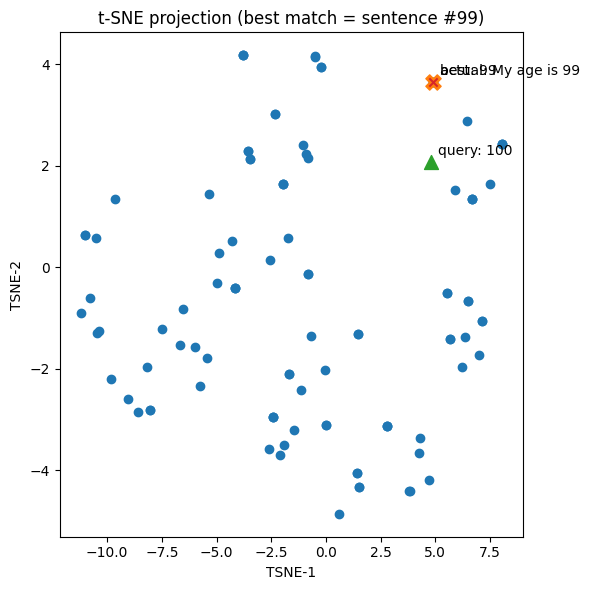

In [25]:
plot_tsne(100, sentences)

In [62]:
def experiment(sentences):
  errors = []
  correct = []
  preds = []


  for age in range(0, 100):
    pred_sentence = simplest_query(age, sentences)
    pred_age = int(pred_sentence.split()[-1])
    preds.append(pred_age)

    true_sentence = failproof(age, sentences)
    true_age = int(true_sentence.split()[-1])
    error = abs(true_age - pred_age)
    errors.append(error)
    correct.append(error <= 2)
  return preds, errors, correct

In [67]:
def plot_concentration(sentences):
  ages = np.arange(100)
  print(len(ages))
  preds, errors, correct = experiment(sentences)
  print(len(preds))
  print(len(errors))

  plt.figure(figsize=(6,6))
  sc = plt.scatter(ages, preds, c = errors, cmap='coolwarm', s=30)
  plt.plot([0,99],[0,99])
  plt.colorbar(sc, label='|pred - true|')
  plt.xlabel("True age")
  plt.ylabel("Predicted age")
  plt.title("Age prediction")
  plt.show()
  return correct

100
100
100


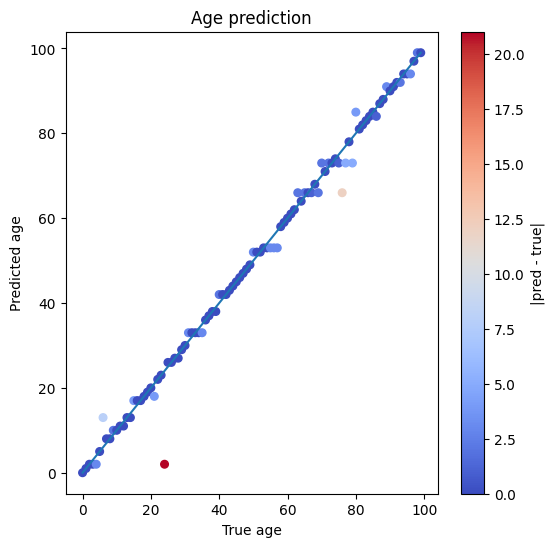

In [68]:
correct = plot_concentration(sentences)

In [70]:
corrects = 0
for i in correct:
  if i:
    corrects+=1
print("accuracy: ", corrects/len(correct))

accuracy:  0.83
